### Exploring the influence of the regularization parameter in a context of a chaotic(remotely) function, with Square Exponential, Matern32 and Matern5

ValueError: x and y must be the same size

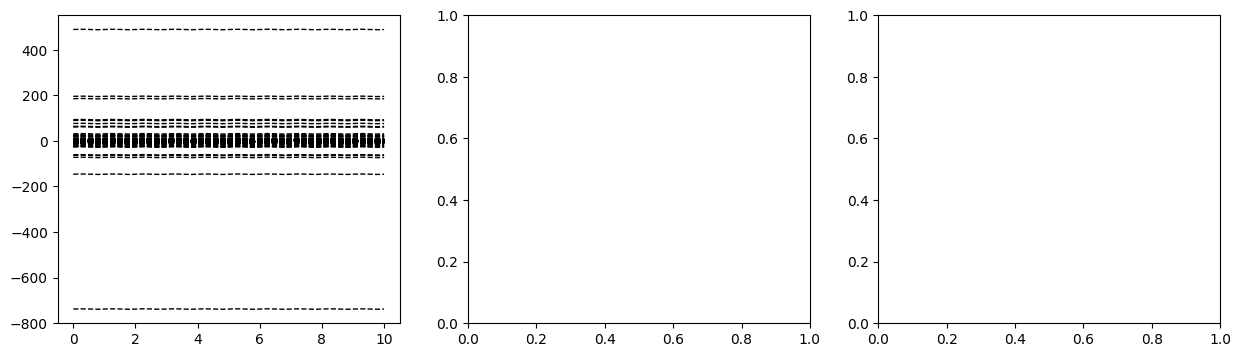

In [3]:
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')
from kernax.stationary import SEKernel, Matern32Kernel, PeriodicKernel
import numpy as np
import KRR

kernel = SEKernel(1.0)

X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = np.squeeze(np.sin(2*np.pi*X) + 0.5*np.random.standard_cauchy(size=X.shape[0]))
rng = np.random.RandomState(1)
training_indices = rng.choice(X.shape[0], size=10, replace=False)  
X_train, y_train = X[training_indices], y[training_indices]

X_plot = np.linspace(0, 10, 400).reshape(-1,1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for a, ax in enumerate(axes):
    gp = KRR.KRR(X_train, Kernel=kernel, RidgeCoeff=1e-6/(a+1)+1, NormalizeObs=True).fit(y_train)
    PosteriorFunction = gp.predict(X_plot)
    ax.plot(X, y, 'k--', lw=1, label='Real function')
    ax.scatter(X_train.ravel(), y_train, c='red', s=30)   
    ax.plot(X_plot, PosteriorFunction, 'b-', label='Mean')
    ax.set_title('Square Exponential')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()